In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from logistic_lasso_regression_fista import LogisticLassoRegressionFISTA

## Spambase

In [2]:
X_spam = pd.read_csv("data/.ipynb_checkpoints/spambase/X.csv")
y_spam = pd.read_csv("data/.ipynb_checkpoints/spambase/Y.csv").iloc[:, 0]

In [3]:
X_spam.shape

(4601, 56)

In [4]:
X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X_spam, 
    y_spam,
    test_size=0.2,
    train_size=0.8, 
)

In [5]:
scaler = MinMaxScaler()
X_spam_train_scaled = scaler.fit_transform(X_spam_train)
X_spam_test_scaled = scaler.transform(X_spam_test)

In [6]:
model = LogisticLassoRegressionFISTA(
    lambda_=0.01,
    max_iter=1000,
    stop_condition=1e-6,
)

model.fit(X_train=X_spam_train_scaled, y_train=y_spam_train)

In [7]:
y_spam_proba = model.predict_proba(X_test=X_spam_test_scaled)
y_spam_pred = (y_spam_proba >= 0.5).astype(int)

In [8]:
print("Iterations:", model.n_iter_)
print("Intercept:", model.intercept_)
print("Number of zero coefficients:", np.sum(model.beta_ == 0.0))
print("Accuracy:", accuracy_score(y_spam_test, y_spam_pred))
print("ROC AUC:", roc_auc_score(y_spam_test, y_spam_proba))

Iterations: 976
Intercept: -0.7131482694046488
Number of zero coefficients: 53
Accuracy: 0.6688382193268186
ROC AUC: 0.8109351695336582


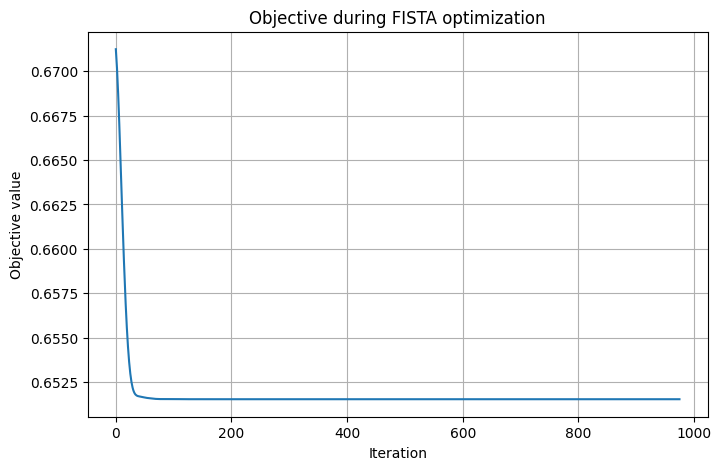

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(model.objective_history_)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Objective during FISTA optimization")
plt.grid(True)
plt.show()